# Deep Learning Assignment 3 - Part 1

##  Text Generation

Student 1: Rajaa Haj 322512690

Student 2: Aseel Shaheen 212393532



In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# *Imports*

In [27]:
import pandas as pd
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader,TensorDataset
from google.colab import files
import os
import random



## *Study the data:*

### Load the CSV:

we will start by loading the Songs CSV file into Dataframe using pandas and showcase a couple of rows from it.





In [3]:
# Load the data from the csv file
data_path='/content/drive/MyDrive/Songs.csv'
data=pd.read_csv(data_path, encoding='utf-8')
data.head(n=10) # Display the first 10 rows of the data

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

1) we will print all of the artist's names and show how many songs are associated with each artists

In [4]:
# count the number of songs assoicated for each artist
artist_song_counts=data['Artist'].value_counts()

for artist, count in artist_song_counts.items():

  print(f"{artist}: {count} songs")

Taylor Swift: 50 songs
Billie Eilish: 50 songs
David Bowie: 50 songs
Billy Joel: 50 songs
Eric Clapton: 50 songs
Leonard Cohen: 50 songs
Bruce Springsteen: 40 songs
The Beatles: 35 songs
Vance Joy: 30 songs
Bryan Adams: 30 songs
Lana Del Rey: 30 songs
Nat King Cole: 30 songs
​twenty one pilots: 30 songs
Elton John: 30 songs
Ray LaMontagne: 30 songs
John Denver: 30 songs
Frank Sinatra: 30 songs
George Michael: 30 songs
Queen: 30 songs
Ed Sheeran: 20 songs
Bob Dylan: 20 songs


2)  We will print the size of the dataset and how many songs are there.

In [5]:
data_size=data.shape

print(f"The size of the dataset is {data_size} \n")
print(f"The number of rows in the dataset is {data_size[0]} \n")
print(f"The number of columns in the dataset is {data_size[1]} \n")

songs_num= len(data)

print(f"The number of songs in the dataset is {songs_num}")



The size of the dataset is (745, 3) 

The number of rows in the dataset is 745 

The number of columns in the dataset is 3 

The number of songs in the dataset is 745


3) We will print the average number of characters and words of a song for all songs lyrics in the dataset ( the average length of a song).



In [6]:
total_char=0
total_words=0


filtered_data=data.dropna(subset=['Lyrics'])

for lyrics in filtered_data['Lyrics']:

  total_char+=len(lyrics)
  total_words+=len(lyrics.split())

avg_char=total_char/songs_num
avg_word=total_words/songs_num


print(f"The average number of characters per song : {avg_char} \n")
print(f"The average number of words per song : {avg_word} \n")

The average number of characters per song : 1403.3476510067114 

The average number of words per song : 276.26040268456376 



4)  We will print the top 3 most used words in the congs and visualize the data using word cloud image .

The Top 3 most used words is:

the : 7458 times 

I : 6719 times 

you : 5475 times 



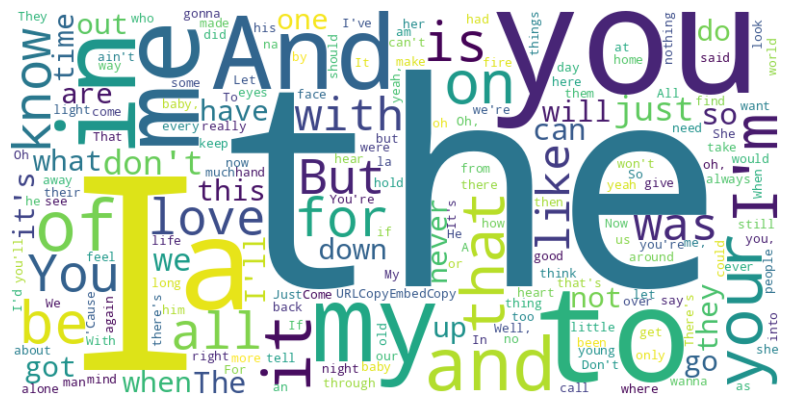

In [7]:

all_lyrics=' '.join(data['Lyrics'].tolist())
all_words=all_lyrics.split()
words_counts=Counter(all_words)

# get the top 3 used words
top_3_words=words_counts.most_common(3)

# print the top 3 used words
print("The Top 3 most used words is:\n")
for word, count in top_3_words:

  print(f"{word} : {count} times \n")


# Display the word cloud

word_cloud=WordCloud(width=800, height =400 , background_color='white').generate_from_frequencies(words_counts)

plt.figure(figsize=(10,5))
plt.imshow(word_cloud , interpolation='bilinear')
plt.axis('off')
plt.show()






# *Preprocessing:*  



*   We add the function **preprocess_data(text)** to clean the text by : removing unnecessary symbols and keep only english letters and  removing extra whitespaces.

  **Note:** By examining the dataset , we notice that at the end of many song lyric, the words : "urlcopyembedcopy" or "embedshare" fequently appear. These words are not part of the actual lyrics , so we remove them during preprocessing.
  

* We apply this function to the dataset and create a corpus from the cleaned lyrics .

*   In order to encode the data before training the model :<br>
1) We start by Tokenizing the Corpus by splitting the cleaned corpus into individual words , then creating a vocabulary dictionary where each word is mapped to numerical index . <br>
2) we convert the words to sequences by replacing each word from the vocab with its corresponding numerical index and create a list of numbers to representing all the corpus .<br>
3) We prepare input_outupt pairs of sequences for training : we define a fixed sequence length (sequence_length=50) and use sliding window approach (step=1)  to ensure sequences overlap. So , each input sequence consists of sequence_length words and the target output is the next word in the sequence .  








In [12]:

def preprocess_data(text):

  if isinstance(text,str):
      text=text.lower()
      # keep only letters and spaces, and newlines
      text=re.sub(r"[^a-z'\s\n]","",text)
      # remove unwanted artifacts
      text=re.sub(r"urlcopyembedcopy", "", text)
      text=re.sub(r"embedshare","", text)
      # replase multiple newlines into a single new line
      text=re.sub(r"\n+","\n",text)
      # remove extra spaces (except newlines)
      text=re.sub(r"[^\S\n]+"," ",text).strip()

      return text

  return ""

# clean the data
data["Prepocessed_Lyrics"]=data["Lyrics"].dropna().apply(preprocess_data)


# filter out empty strings after preprocessing
#data["Prepocessed_Lyrics"]=data["Prepocessed_Lyrics"].apply(lambda x:x if x else None).dropna()


# create the corpus
corpus= " ".join(data["Prepocessed_Lyrics"].dropna())


#Encode the data
#step 1: Tokenize the text

words=re.findall(r"\S+|\n",corpus)

# step 2: Create a vocabulary from unique words
word_counts=Counter(words)  # count occurrences of each word
# create a vocabulary
vocab=list(word_counts.keys())

#Add special toknes for unkown words an padding
vocab.extend(["<UNK>","<PAD>"])
# sort the vocab
vocab.sort()


# step 3: create mapping from words to index
word_to_index={ word:i for i, word in enumerate(vocab)}
index_to_word={i: word for word,i in word_to_index.items()}

# step 4: encode all the corpus into a list of numbers
# replace unknown words with <UNK>
encoded_corpus=[word_to_index.get(word,word_to_index["<UNK>"]) for word in words]

# step 5: Prepare Sequences
sequence_length=150
step=1 # to ensure overlapping sequences

input_sequences=[]
target_sequences=[]

for i in range(0,len(encoded_corpus)-sequence_length,step):

  sequence=(encoded_corpus[i:i+sequence_length]) # input sequence of size sequence length
  target=(encoded_corpus[i+sequence_length])    # next word as target

  # Pad sequences shorter than sequence_length with <PAD>
  if len(sequence) < sequence_length:
    sequence+= [word_to_index["<PAD>"]]*(sequence_length-len(sequence))





  input_sequences.append(sequence)
  target_sequences.append(target)



# convert lists to numy arrays for training
input_sequences=np.array(input_sequences)
target_sequences=np.array(target_sequences)




# *Model Definition and training :*

## *Define The Model:*

We will use LSTM model to handle sequential data .
We choose the loss function :
The Optimizer :


In [13]:

class LSTMModel(nn.Module):


  def __init__(self, vocab_size, embedding_dim=100, hidden_dim=128,num_layers=2):

    super(LSTMModel, self).__init__()
    self.embedding=nn.Embedding(vocab_size, embedding_dim)
    self.lstm=nn.LSTM(embedding_dim,hidden_dim,num_layers,batch_first=True)
    self.fc=nn.Linear(hidden_dim,vocab_size)


  def forward(self,x):

    embedded=self.embedding(x)
    lstm_out,_=self.lstm(embedded)
    output=self.fc(lstm_out[:,-1,:])

    return output




## Train the model :

In [14]:
# convert to PyTorch tensors
X=torch.tensor(input_sequences, dtype=torch.long)
y=torch.tensor(target_sequences,dtype=torch.long)

# create DataLoader
batch_size=64
dataset=TensorDataset(X,y)
dataloader=DataLoader(dataset,batch_size=batch_size , shuffle=True )



vocab_size=len(vocab)
model=LSTMModel(vocab_size).to(device)
criterion= nn.CrossEntropyLoss(ignore_index=word_to_index["<PAD>"])
learning_rate=0.001
optimizer=optim.Adam(model.parameters(), lr=learning_rate)

print("training the model ......")

num_epochs=100
losses=[]
for epoch in range(num_epochs):
    total_loss=0
    for batch_X,batch_y in dataloader:
      batch_X,batch_y=batch_X.to(device),batch_y.to(device)

      # forward pass
      outputs=model(batch_X)



      #calculate loss
      loss=criterion(outputs,batch_y)

      # Backward pass and optimization
      optimizer.zero_grad()
      loss.backward()
      #clipping gradient
      torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
      optimizer.step()


      total_loss+=loss.item()

    # calculate average loss for each epoch
    avg_loss=total_loss/len(dataloader)
    losses.append(avg_loss)
    print(f"Epoch[{ epoch+1}/{num_epochs}],Loss: {avg_loss:.4f}")

training the model ......
Epoch[1/100],Loss: 5.5313
Epoch[2/100],Loss: 4.8209
Epoch[3/100],Loss: 4.3959
Epoch[4/100],Loss: 4.0399
Epoch[5/100],Loss: 3.7394
Epoch[6/100],Loss: 3.4796
Epoch[7/100],Loss: 3.2538
Epoch[8/100],Loss: 3.0532
Epoch[9/100],Loss: 2.8748
Epoch[10/100],Loss: 2.7169
Epoch[11/100],Loss: 2.5751
Epoch[12/100],Loss: 2.4495
Epoch[13/100],Loss: 2.3343
Epoch[14/100],Loss: 2.2317
Epoch[15/100],Loss: 2.1370
Epoch[16/100],Loss: 2.0494
Epoch[17/100],Loss: 1.9707
Epoch[18/100],Loss: 1.8961
Epoch[19/100],Loss: 1.8289
Epoch[20/100],Loss: 1.7671
Epoch[21/100],Loss: 1.7087
Epoch[22/100],Loss: 1.6566
Epoch[23/100],Loss: 1.6054
Epoch[24/100],Loss: 1.5579
Epoch[25/100],Loss: 1.5150
Epoch[26/100],Loss: 1.4742
Epoch[27/100],Loss: 1.4351
Epoch[28/100],Loss: 1.4003
Epoch[29/100],Loss: 1.3657
Epoch[30/100],Loss: 1.3335
Epoch[31/100],Loss: 1.3049
Epoch[32/100],Loss: 1.2752
Epoch[33/100],Loss: 1.2499
Epoch[34/100],Loss: 1.2244
Epoch[35/100],Loss: 1.2012
Epoch[36/100],Loss: 1.1799
Epoch[37/10

plot

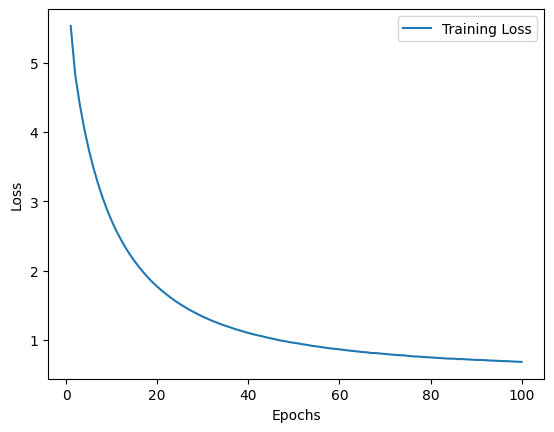

In [15]:
plt.plot(range(1,num_epochs+1) , losses ,label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [39]:
model_path='/content/drive/MyDrive/lstm_model1.pth'
torch.save(model.state_dict(),model_path)

## **Evaluation:**

In [25]:
# Function to generated lyrics with different strategies

def sample_with_temperature(predictions , temperature=1.3):

  predictions=predictions/temperature
  probabilities=torch.nn.functional.softmax(predictions,dim=0)
  return torch.multinomial(probabilities,1).item()



def sample_with_top_p(prediction, top_p=0.92):
   sorted_indx=torch.argsort(prediction,descending=True)
   sorted_prob=torch.nn.functional.softmax(prediction[sorted_indx],dim=0)

   cum_prop=torch.cumsum(sorted_prob.view(-1, sorted_prob.shape[0]),dim=0)
   filtered_indx=sorted_indx[cum_prop[0] <= top_p]
   if len(filtered_indx)==0:
    filtered_indx=sorted_indx

   # Adjust the indexing to work with the modified cum_prop
   selected_indx=filtered_indx[torch.multinomial(sorted_prob[:len(filtered_indx)],1)].item()

   return selected_indx


def sample_with_top_k(prediction,top_k=5):

   probabilities=torch.softmax(prediction,dim=-1)
   top_k_probs, top_k_indx=torch.topk(probabilities,k=top_k)
   sampled_indx=torch.multinomial(top_k_probs,1).item()
   next_token=top_k_indx[sampled_indx].item()

   return next_token




In [44]:

def LyricsGenerator(starting_string , char_count , strategy="argmax", temp=1.3 , top_k=5 , top_p=0.92):

  model.eval()

  # In case the starting string is empty , pick a random word from vocab (excluding special tokens)
  if not starting_string:
    #possible_words=[w for w in word_to_index.keys() if w not in ["<PAD>","<UNK>"]]
    #starting_string=random.choice(possible_words)
    common_words=[word for word,count in word_counts.most_common() if word not in ["<PAD>","<UNK>"]]
    starting_string=common_words[1]

  words=preprocess_data(starting_string)
  words=words.lower().split()
  tokens=[word_to_index.get(word,word_to_index["<UNK>"]) for word in words]
  generated_lyric=starting_string

  while len(generated_lyric) < int(char_count):

    input_tensor=torch.tensor([tokens],dtype=torch.long).to(device)
    with torch.no_grad():

        output=model(input_tensor)
        output=output.squeeze(0)


        #probabilities=torch.softmax(output,dim=-1)

        if strategy=="temperature":
          next_token=sample_with_temperature(output)

        elif strategy=="top_p":
          next_token=sample_with_top_p(output)

        elif strategy=="top_k":

          next_token=sample_with_top_k(output)

        else:

          next_token=torch.argmax(output).item()


        #Apply top-k sampling


    #Stop if <PAD> or <UNK> is generated
    if next_token==word_to_index["<PAD>"] or next_token==word_to_index["<UNK>"]:
      break


    #append the generated word to the text
    generated_lyric+=" "+index_to_word[next_token]
    tokens.append(next_token)

  return generated_lyric





print("Generated Song 1:")
print("strategy : temp")
generated_song1=LyricsGenerator("it's not a silly little moment...",avg_char,strategy="temperature")
print(generated_song1)
print("\n\n\n\n")
print("strategy : top_k")
generated_song2=LyricsGenerator("it's not a silly little moment...",avg_char,strategy="top_k")
print(generated_song2)
print("\n\n\n\n")
generated_song3=LyricsGenerator("it's not a silly little moment...",avg_char,strategy="argmax")
print(generated_song3)
print("\n\n\n\n")
print("strategy : top_p")
generated_song4=LyricsGenerator("it's not a silly little moment...",avg_char,strategy="top_p")
print(generated_song4)
print("\n\n\n\n")

print("**********************************************************************************************************")
print("\nGenerated Song 2:")
generated_song1=LyricsGenerator("Hello, it's me",avg_char,strategy="temperature")
print(generated_song1)
print("\n\n\n\n")
print("strategy : top_k")
generated_song2=LyricsGenerator("Hello it's me",avg_char,strategy="top_k")
print(generated_song2)
print("\n\n\n\n")
generated_song3=LyricsGenerator("Hello it's me",avg_char,strategy="argmax")
print(generated_song3)
print("\n\n\n\n")
print("strategy : top_p")
generated_song4=LyricsGenerator("Hello it's me",avg_char,strategy="top_p")
print(generated_song4)
print("\n\n\n\n")



print("\nGenerated Song 3:")
print("strategy : temp")
generated_song1=LyricsGenerator("",avg_char,strategy="temperature")
print(generated_song1)
print("\n\n\n\n")
print("strategy : top_k")
generated_song2=LyricsGenerator("",avg_char,strategy="top_k")
print(generated_song2)
print("\n\n\n\n")
generated_song3=LyricsGenerator("",avg_char,strategy="argmax")
print(generated_song3)
print("\n\n\n\n")
print("strategy : top_p")
generated_song4=LyricsGenerator("",avg_char,strategy="top_p")
print(generated_song4)
print("\n\n\n\n")



Generated Song 1:
strategy : temp
it's not a silly little moment... all alone 
 i didn't have to protect the better home 
 the best things is more so nice 
 so you'll come running from hard in the dark 
 and if i saw you in the dark street moon if you're not living 
 that we're still yet to come down 
 my boy now now we've got change yeah 
 i was young under the rent of my sex 
 this ain't no place that i find you 
 my life was going to me a woman 
 i have permission to the heart 
 like a girl who cries for three as i am fell for 
 they're so at my lady took a wife and i'll not want to judge the life 
 to say that long 
 every times i fell in love with my love 
 i lay in an makes him 
 like a gold leader i step into her breast and 
 she kissed me in his tiny little room i had a little story 
 we used to do there's one day they come with you 
 when i i'll be there right where it's all too late 
 to get it all through spring 'em 
 our reputation man well country burned cherry man dream 


i start by applying eah strategy and show what the results i get :

for soft max : i get:



# **MODEL - SUMMARY :**

In [42]:
# Print the network summary
print(model)

# Function to calculate the number of trainable parameters
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Calculate the number of trainable parameters
total_params = count_trainable_parameters(model)

print(f'Total trainable parameters: {total_params}')

LSTMModel(
  (embedding): Embedding(9651, 100)
  (lstm): LSTM(100, 128, num_layers=2, batch_first=True)
  (fc): Linear(in_features=128, out_features=9651, bias=True)
)
Total trainable parameters: 2459935
